In [11]:
!pip install pandas numpy scikit-learn xgboost matplotlib seaborn


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
# 读取四个 CSV 文件
train = pd.read_csv('train.csv', parse_dates=['Date'])
test = pd.read_csv('test.csv', parse_dates=['Date'])
features = pd.read_csv('features.csv', parse_dates=['Date'])
stores = pd.read_csv('stores.csv')

In [14]:
# 快速查看每个表的形状和前几行
print("===== 训练集 =====")
print("形状:", train.shape)
display(train.head())

===== 训练集 =====
形状: (421570, 5)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [15]:
print("\n===== 测试集 =====")
print("形状:", test.shape)
display(test.head())


===== 测试集 =====
形状: (115064, 4)


,Store,Dept,Date,IsHoliday
0,1,1,2012-11-02,False
1,1,1,2012-11-09,False
2,1,1,2012-11-16,False
3,1,1,2012-11-23,True
4,1,1,2012-11-30,False


In [16]:
print("\n===== 特征表 =====")
print("形状:", features.shape)
display(features.head())


===== 特征表 =====
形状: (8190, 12)


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [17]:
print("\n===== 商店表 =====")
print("形状:", stores.shape)
display(stores.head())


===== 商店表 =====
形状: (45, 3)


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [18]:
# 合并训练集与特征表（按 Store、Date、IsHoliday 匹配）
train_merged = train.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')

# 再合并商店信息
train_merged = train_merged.merge(stores, on='Store', how='left')

# 查看合并后的形状和前几行
print("合并后训练集形状:", train_merged.shape)
train_merged.head()

合并后训练集形状: (421570, 16)


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


In [19]:
test_merged = test.merge(features, on=['Store', 'Date', 'IsHoliday'], how='left')
test_merged = test_merged.merge(stores, on='Store', how='left')

print("合并后测试集形状:", test_merged.shape)
test_merged.head()

合并后测试集形状: (115064, 15)


,Store,Dept,Date,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2012-11-02,False,55.32,3.386,6766.44,5147.70,50.82,3639.90,2737.42,223.462779,6.573,A,151315
1,1,1,2012-11-09,False,61.24,3.314,11421.32,3370.89,40.28,4646.79,6154.16,223.481307,6.573,A,151315
2,1,1,2012-11-16,False,52.92,3.252,9696.28,292.10,103.78,1133.15,6612.69,223.512911,6.573,A,151315
3,1,1,2012-11-23,True,56.23,3.211,883.59,4.17,74910.32,209.91,303.32,223.561947,6.573,A,151315
4,1,1,2012-11-30,False,52.34,3.207,2460.03,NaN,3838.35,150.57,6966.34,223.610984,6.573,A,151315


In [20]:
# 检查合并后训练集的缺失值情况
print("训练集缺失值数量：")
print(train_merged.isnull().sum())
print("\n" + "="*50)
print("测试集缺失值数量：")
print(test_merged.isnull().sum())

训练集缺失值数量：
Store                0
Dept                 0
Date                 0
Weekly_Sales         0
IsHoliday            0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
dtype: int64

测试集缺失值数量：
Store               0
Dept                0
Date                0
IsHoliday           0
Temperature         0
Fuel_Price          0
MarkDown1         149
MarkDown2       28627
MarkDown3        9829
MarkDown4       12888
MarkDown5           0
CPI             38162
Unemployment    38162
Type                0
Size                0
dtype: int64


In [33]:
# ========== 数据清洗终极版 ==========

# 1. 先看看当前数据框有哪些列（方便排查）
print("训练集列名：", list(train_merged.columns))
print("测试集列名：", list(test_merged.columns))

# 2. 定义促销列
markdowns = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']

# 3. 训练集处理
train_merged[markdowns] = train_merged[markdowns].fillna(0)

# 处理 CPI 和 Unemployment：先尝试 ffill，不行就填 0
try:
    train_merged['CPI'] = train_merged['CPI'].fillna(method='ffill')
except:
    train_merged['CPI'] = train_merged['CPI'].fillna(0)

try:
    train_merged['Unemployment'] = train_merged['Unemployment'].fillna(method='ffill')
except:
    train_merged['Unemployment'] = train_merged['Unemployment'].fillna(0)

# 处理 IsHoliday 重复列：找到所有含 IsHoliday 的列
holiday_cols = [c for c in train_merged.columns if 'IsHoliday' in c]
if len(holiday_cols) > 1:
    train_merged.drop(columns=holiday_cols[1:], inplace=True)
    train_merged.rename(columns={holiday_cols[0]: 'IsHoliday'}, inplace=True)
elif len(holiday_cols) == 1 and holiday_cols[0] != 'IsHoliday':
    train_merged.rename(columns={holiday_cols[0]: 'IsHoliday'}, inplace=True)
# 如果没有 IsHoliday 列，什么都不做

# 4. 测试集处理（完全一样）
test_merged[markdowns] = test_merged[markdowns].fillna(0)

try:
    test_merged['CPI'] = test_merged['CPI'].fillna(method='ffill')
except:
    test_merged['CPI'] = test_merged['CPI'].fillna(0)

try:
    test_merged['Unemployment'] = test_merged['Unemployment'].fillna(method='ffill')
except:
    test_merged['Unemployment'] = test_merged['Unemployment'].fillna(0)

holiday_cols_test = [c for c in test_merged.columns if 'IsHoliday' in c]
if len(holiday_cols_test) > 1:
    test_merged.drop(columns=holiday_cols_test[1:], inplace=True)
    test_merged.rename(columns={holiday_cols_test[0]: 'IsHoliday'}, inplace=True)
elif len(holiday_cols_test) == 1 and holiday_cols_test[0] != 'IsHoliday':
    test_merged.rename(columns={holiday_cols_test[0]: 'IsHoliday'}, inplace=True)

# 5. 最终检查
print("\n✅ 训练集缺失值：")
print(train_merged.isnull().sum())
print("\n✅ 测试集缺失值：")
print(test_merged.isnull().sum())

训练集列名： ['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size']
测试集列名： ['Store', 'Dept', 'Date', 'IsHoliday', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment', 'Type', 'Size']

✅ 训练集缺失值：
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64

✅ 测试集缺失值：
Store           0
Dept            0
Date            0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64


In [34]:
# ========== 提取时间特征 ==========

def add_time_features(df):
    df['Year'] = df['Date'].dt.year
    df['Month'] = df['Date'].dt.month
    df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
    df['Quarter'] = df['Date'].dt.quarter
    df['DayOfYear'] = df['Date'].dt.dayofyear
    return df

train_merged = add_time_features(train_merged)
test_merged = add_time_features(test_merged)

print("训练集新增列：Year, Month, Week, Quarter, DayOfYear")
print(train_merged[['Date','Year','Month','Week','Quarter']].head())
print("\n测试集新增列：")
print(test_merged[['Date','Year','Month','Week','Quarter']].head())

训练集新增列：Year, Month, Week, Quarter, DayOfYear
             Date  Year  Month  Week  Quarter
0      2010-02-05  2010      2     5        1
277665 2010-02-05  2010      2     5        1
277808 2010-02-05  2010      2     5        1
277951 2010-02-05  2010      2     5        1
278094 2010-02-05  2010      2     5        1

测试集新增列：
        Date  Year  Month  Week  Quarter
0 2012-11-02  2012     11    44        4
1 2012-11-09  2012     11    45        4
2 2012-11-16  2012     11    46        4
3 2012-11-23  2012     11    47        4
4 2012-11-30  2012     11    48        4


In [35]:
# 定义特征列（确保这些列在 train_merged 中都存在）
feature_cols = [
    'Year', 'Month', 'Week', 'Quarter', 'DayOfYear',
    'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5',
    'CPI', 'Unemployment', 'IsHoliday'
]

target_col = 'Weekly_Sales'

# 检查列是否存在
missing = [c for c in feature_cols if c not in train_merged.columns]
if missing:
    print(f"❌ 缺少特征列：{missing}")
else:
    X = train_merged[feature_cols]   # 特征矩阵
    y = train_merged[target_col]     # 目标向量
    print(f"✅ 特征矩阵形状：{X.shape}，目标向量长度：{len(y)}")

✅ 特征矩阵形状：(421570, 13)，目标向量长度：421570


In [36]:
# 按日期排序
train_merged = train_merged.sort_values('Date')
X = train_merged[feature_cols]
y = train_merged[target_col]

# 取前80%作为训练集，后20%作为验证集
split_idx = int(len(train_merged) * 0.8)
X_train = X.iloc[:split_idx]
X_val = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_val = y.iloc[split_idx:]

print(f"训练集样本数：{len(X_train)}，验证集样本数：{len(X_val)}")

训练集样本数：337256，验证集样本数：84314


In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 创建模型对象
model_lr = LinearRegression()

# 训练
model_lr.fit(X_train, y_train)

# 在验证集上预测
y_pred_lr = model_lr.predict(X_val)

# 评估
mae_lr = mean_absolute_error(y_val, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_val, y_pred_lr))

print(f"📊 线性回归验证集结果：")
print(f"MAE (平均绝对误差)：{mae_lr:.2f} 美元")
print(f"RMSE (均方根误差)：{rmse_lr:.2f} 美元")

📊 线性回归验证集结果：
MAE (平均绝对误差)：14973.80 美元
RMSE (均方根误差)：21801.43 美元


In [38]:
from sklearn.ensemble import RandomForestRegressor

# 创建随机森林模型（n_estimators=100 表示100棵树，n_jobs=-1 使用所有CPU加速）
model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)

# 训练
model_rf.fit(X_train, y_train)

# 预测验证集
y_pred_rf = model_rf.predict(X_val)

# 评估
mae_rf = mean_absolute_error(y_val, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_val, y_pred_rf))

print(f"🌲 随机森林验证集结果：")
print(f"MAE：{mae_rf:.2f} 美元")
print(f"RMSE：{rmse_rf:.2f} 美元")

# 对比两个模型
print(f"\n📈 线性回归 RMSE：{rmse_lr:.2f}  →  随机森林 RMSE：{rmse_rf:.2f}")

🌲 随机森林验证集结果：
MAE：14496.97 美元
RMSE：21490.49 美元

📈 线性回归 RMSE：21801.43  →  随机森林 RMSE：21490.49


In [39]:
# 用随机森林模型（效果更好）预测测试集
X_test = test_merged[feature_cols]
test_merged['Predicted_Sales'] = model_rf.predict(X_test)

# 查看前几条预测结果
print("测试集预测结果（前10行）：")
print(test_merged[['Date', 'Store', 'Dept', 'Predicted_Sales']].head(10))

# 保存为CSV（可选）
output = test_merged[['Date', 'Store', 'Dept', 'Predicted_Sales']]
output.to_csv('walmart_predictions.csv', index=False)
print("\n✅ 预测结果已保存到 walmart_predictions.csv")

测试集预测结果（前10行）：
        Date  Store  Dept  Predicted_Sales
0 2012-11-02      1     1     20424.308277
1 2012-11-09      1     1     21855.126546
2 2012-11-16      1     1     20676.816932
3 2012-11-23      1     1     20759.660756
4 2012-11-30      1     1     15425.902884
5 2012-12-07      1     1     16626.407636
6 2012-12-14      1     1     17546.549897
7 2012-12-21      1     1     21412.348480
8 2012-12-28      1     1     20602.280969
9 2013-01-04      1     1     13549.050868

✅ 预测结果已保存到 walmart_predictions.csv


C:\Users\asus\AppData\Local\Temp\ipykernel_20800\3583862119.py:10: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_20800\3583862119.py:10: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_20800\3583862119.py:10: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_20800\3583862119.py:10: UserWarning: Glyph 24471 (\N{CJK UNIFIED IDEOGRAPH-5F97}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_20800\3583862119.py:10: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\asus\AppData\Local\Temp\ipykernel_20800\3583862119.py:10: UserWarning: Glyph 38543 (\N{CJK UNIFIED IDEOGRAPH-968F}) missi

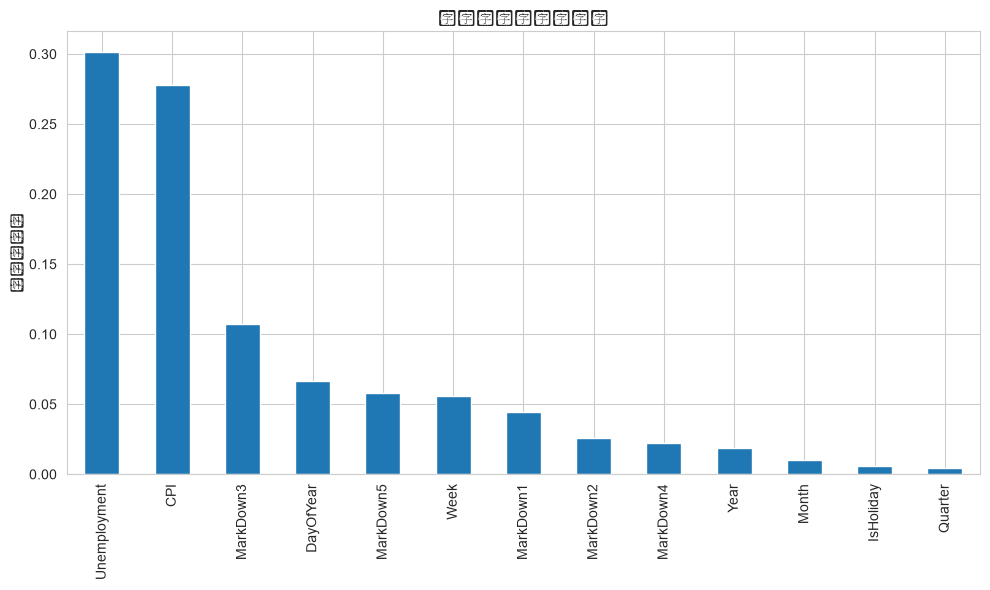

最重要的5个特征：
Unemployment    0.301141
CPI             0.278127
MarkDown3       0.107201
DayOfYear       0.066927
MarkDown5       0.058008
dtype: float64


In [40]:
# 获取特征重要性
importance = model_rf.feature_importances_
feat_imp = pd.Series(importance, index=feature_cols).sort_values(ascending=False)

# 绘制柱状图
plt.figure(figsize=(10,6))
feat_imp.plot(kind='bar')
plt.title('随机森林特征重要性')
plt.ylabel('重要性得分')
plt.tight_layout()
plt.show()

# 打印前5个最重要特征
print("最重要的5个特征：")
print(feat_imp.head())

In [43]:
with open('.gitignore', 'w') as f:
    f.write("""
.venv/
__pycache__/
*.pyc
.ipynb_checkpoints/
.DS_Store
data/
""")